In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.utils as vutils
from torchvision.models import inception_v3
from PIL import Image
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
from skimage.metrics import structural_similarity as ssim


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
class BreakHisDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = []
        valid_ext = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')

        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(valid_ext):
                    self.image_paths.append(os.path.join(root, file))

        print(f"[INFO] Total BreaKHis images found: {len(self.image_paths)}")

        self.transform = transforms.Compose([
            transforms.Resize((96, 96)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img)


In [4]:
ROOT_DIR = "/kaggle/input/breakhis/BreaKHis_v1"

dataset = BreakHisDataset(ROOT_DIR)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    drop_last=True
)


[INFO] Total BreaKHis images found: 7909


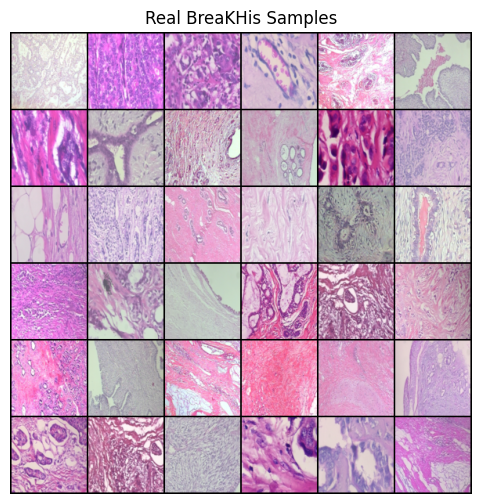

In [5]:
real_batch = next(iter(dataloader))

plt.figure(figsize=(6,6))
plt.axis("off")
plt.title("Real BreaKHis Samples")
plt.imshow(
    vutils.make_grid(real_batch[:36], nrow=6, normalize=True).permute(1,2,0)
)
plt.show()


In [6]:
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 6, 1, 0),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)


In [7]:
class Critic(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1),
            nn.InstanceNorm2d(ndf*2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1),
            nn.InstanceNorm2d(ndf*4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1),
            nn.InstanceNorm2d(ndf*8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, 1, 6, 1, 0)
        )

    def forward(self, x):
        return self.main(x).view(-1)


In [8]:
netG = Generator().to(device)
netC = Critic().to(device)

lr = 1e-4
optimizer_G = torch.optim.Adam(netG.parameters(), lr=lr, betas=(0.0, 0.9))
optimizer_C = torch.optim.Adam(netC.parameters(), lr=lr, betas=(0.0, 0.9))

nz = 100


In [9]:
def gradient_penalty(critic, real, fake):
    batch_size = real.size(0)
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = epsilon * real + (1 - epsilon) * fake
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)

    grad = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True
    )[0]

    grad = grad.view(batch_size, -1)
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()


In [10]:
num_epochs = 60
n_critic = 5
lambda_gp = 10
print_interval = 200

fixed_noise = torch.randn(64, nz, 1, 1, device=device)

for epoch in range(num_epochs):
    for batch_idx, real in enumerate(dataloader):
        real = real.to(device)
        b_size = real.size(0)

        # ---- Train Critic ----
        for _ in range(n_critic):
            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake = netG(noise)

            critic_real = netC(real)
            critic_fake = netC(fake.detach())

            gp = gradient_penalty(netC, real, fake)
            loss_C = -(critic_real.mean() - critic_fake.mean()) + lambda_gp * gp

            optimizer_C.zero_grad()
            loss_C.backward()
            optimizer_C.step()

        # ---- Train Generator ----
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        loss_G = -netC(fake).mean()

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        if (batch_idx + 1) % print_interval == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"Batch [{batch_idx+1}/{len(dataloader)}] "
                f"Loss_C: {loss_C.item():.4f} "
                f"Loss_G: {loss_G.item():.4f}"
            )

    print(f"Epoch [{epoch+1}/{num_epochs}] completed")


Epoch [1/60] completed
Epoch [2/60] completed
Epoch [3/60] completed
Epoch [4/60] completed
Epoch [5/60] completed
Epoch [6/60] completed
Epoch [7/60] completed
Epoch [8/60] completed
Epoch [9/60] completed
Epoch [10/60] completed
Epoch [11/60] completed
Epoch [12/60] completed
Epoch [13/60] completed
Epoch [14/60] completed
Epoch [15/60] completed
Epoch [16/60] completed
Epoch [17/60] completed
Epoch [18/60] completed
Epoch [19/60] completed
Epoch [20/60] completed
Epoch [21/60] completed
Epoch [22/60] completed
Epoch [23/60] completed
Epoch [24/60] completed
Epoch [25/60] completed
Epoch [26/60] completed
Epoch [27/60] completed
Epoch [28/60] completed
Epoch [29/60] completed
Epoch [30/60] completed
Epoch [31/60] completed
Epoch [32/60] completed
Epoch [33/60] completed
Epoch [34/60] completed
Epoch [35/60] completed
Epoch [36/60] completed
Epoch [37/60] completed
Epoch [38/60] completed
Epoch [39/60] completed
Epoch [40/60] completed
Epoch [41/60] completed
Epoch [42/60] completed
E

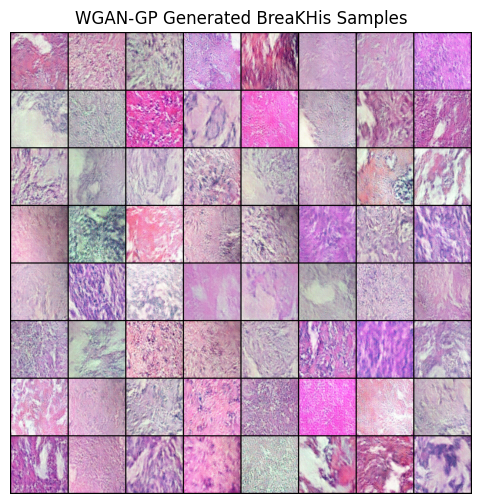

In [11]:
netG.eval()
with torch.no_grad():
    fake = netG(fixed_noise).cpu()

plt.figure(figsize=(6,6))
plt.axis("off")
plt.title("WGAN-GP Generated BreaKHis Samples")
plt.imshow(
    vutils.make_grid(fake, nrow=8, normalize=True).permute(1,2,0)
)
plt.show()


In [12]:
def generate_images(netG, n=1000):
    imgs = []
    with torch.no_grad():
        for _ in range(n // 64):
            z = torch.randn(64, nz, 1, 1, device=device)
            imgs.append(netG(z).cpu())
    return torch.cat(imgs)

real_images = torch.cat([batch for batch in dataloader][:16])[:1000]
fake_images = generate_images(netG, 1000)


In [13]:
inception = inception_v3(pretrained=True).to(device)
inception.fc = nn.Identity()
inception.eval()

def inception_features(images):
    feats = []
    with torch.no_grad():
        for i in range(0, len(images), 32):
            batch = F.interpolate(images[i:i+32].to(device), size=299)
            feats.append(inception(batch).cpu())
    return torch.cat(feats).numpy()

real_feats = inception_features(real_images)
fake_feats = inception_features(fake_images)

mu_r, mu_f = real_feats.mean(0), fake_feats.mean(0)
cov_r, cov_f = np.cov(real_feats, rowvar=False), np.cov(fake_feats, rowvar=False)
covmean = sqrtm(cov_r @ cov_f)
if np.iscomplexobj(covmean):
    covmean = covmean.real

fid = np.sum((mu_r - mu_f)**2) + np.trace(cov_r + cov_f - 2*covmean)
print("FID:", fid)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 186MB/s]  


FID: 100.60677505229822


In [14]:
ssim_scores = []
for i in range(100):
    r = real_images[i].permute(1,2,0).numpy()
    f = fake_images[i].permute(1,2,0).numpy()
    ssim_scores.append(ssim(r, f, channel_axis=2, data_range=2))

print("SSIM:", np.mean(ssim_scores))


SSIM: 0.124471284


In [15]:
def compute_mmd(x, y, sigma=1.0):
    xx = torch.mm(x, x.t())
    yy = torch.mm(y, y.t())
    xy = torch.mm(x, y.t())

    rx = xx.diag().unsqueeze(0)
    ry = yy.diag().unsqueeze(0)

    Kxx = torch.exp(-(rx.t() + rx - 2*xx) / (2*sigma))
    Kyy = torch.exp(-(ry.t() + ry - 2*yy) / (2*sigma))
    Kxy = torch.exp(-(rx.t() + ry - 2*xy) / (2*sigma))

    return Kxx.mean() + Kyy.mean() - 2*Kxy.mean()

mmd = compute_mmd(
    torch.tensor(real_feats[:200]),
    torch.tensor(fake_feats[:200])
)
print("MMD:", mmd.item())


MMD: 0.009999999776482582


In [16]:
torch.save(netG.state_dict(), "wgan_gp_breakhis_generator.pth")
torch.save(netC.state_dict(), "wgan_gp_breakhis_critic.pth")


In [17]:
print("FID:", fid)
print("SSIM:", np.mean(ssim_scores))
print("MMD:", mmd.item())

FID: 100.60677505229822
SSIM: 0.124471284
MMD: 0.009999999776482582
